In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/content/Medical Insurance Dataset.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


(1338, 7)

In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [15]:
df.duplicated().sum()

df = df.drop_duplicates()

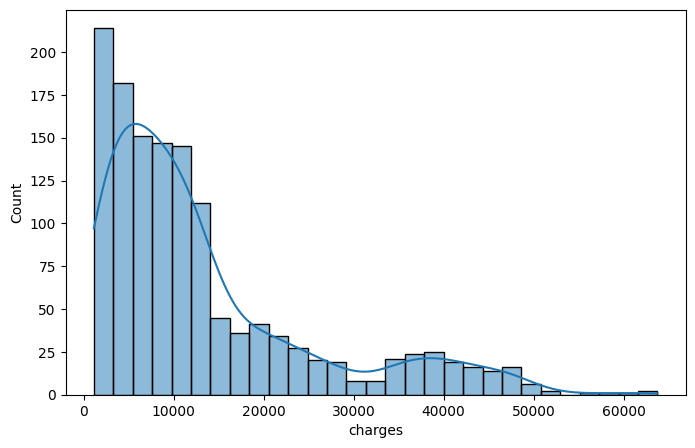

In [10]:
# plt.figure(figsize=(8,5))
# sns.histplot(df['charges'], kde=True)
# plt.show()

In [12]:
# temp_df = df.copy()
# le = LabelEncoder()

# for col in ['sex','smoker','region']:
#   temp_df[col] = le.fit_transform(temp_df[col])




In [14]:
# plt.figure(figsize=(8,6))
# sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')
# plt.show()

In [16]:
df['sex'] = LabelEncoder().fit_transform(df['sex'])
df['smoker'] = LabelEncoder().fit_transform(df['smoker'])
df['region'] = LabelEncoder().fit_transform(df['region'])

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [18]:
x=df.drop('charges', axis=1)

y=df['charges']


In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [25]:
model = Sequential()

model.add(Dense(units=64,activation='relu',input_dim=x_train.shape[1]))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=16,activation='relu'))
model.add(Dense(units=1,activation='linear'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])


In [27]:
history = model.fit(x_train,y_train,epochs=100,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 307072096.0000 - mae: 13126.0957 - val_loss: 303486336.0000 - val_mae: 12585.5850
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 306279936.0000 - mae: 13097.6514 - val_loss: 302359232.0000 - val_mae: 12544.1963
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 304401312.0000 - mae: 13029.4561 - val_loss: 299475200.0000 - val_mae: 12437.6484
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 299652448.0000 - mae: 12859.2959 - val_loss: 292685120.0000 - val_mae: 12182.8975
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 289216800.0000 - mae: 12475.4980 - val_loss: 278641312.0000 - val_mae: 11638.2334
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 269489472.0000 - mae: 11699.2686 - val_loss: 253280144.0000 - val_mae: 10587.9648
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 236813264.0000 - mae: 10385.6436 - val_loss: 216200800.0000 - val_mae: 9027.4316
Epoch 8/100
2

In [29]:
y_pred = model.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [30]:
y_pred = y_pred.flatten()

In [31]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

MAE: 9233.590312199976
RMSE: 12000.949548180402
R2 Score: 0.21622836879136198


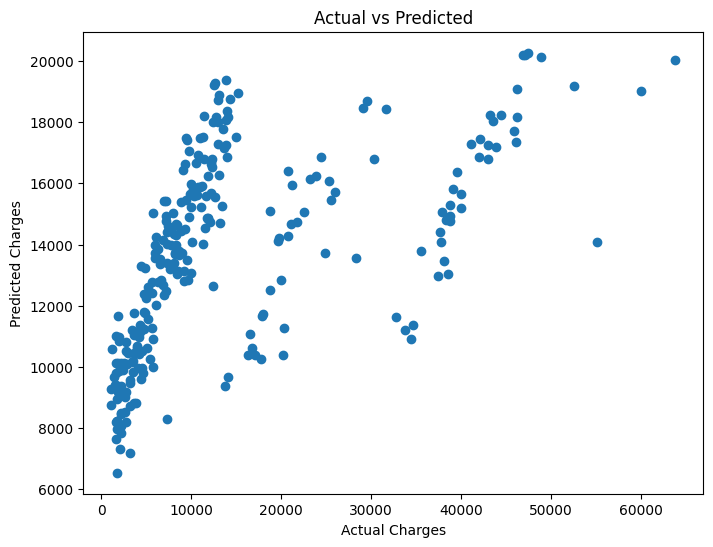

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()

In [37]:
new_customer = [[
    30,   # age
    1,    # sex
    28.5, # bmi
    2,    # children
    0,    # smoker
    3     # region
]]

In [43]:
new_customer = scaler.transform(new_customer)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [44]:
prediction = model.predict(new_customer)

print("Predicted Insurance Cost =", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Insurance Cost = 1.1750536
